# Vision-Based Landslide Forecasting (PyTorch)

This notebook trains a **Baseline CNN** and a **ResNet50** model using PyTorch, aligning with the assignment's forecasting strategy and preventing data leakage via geographic splitting.

In [8]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Geographic Data Split (Preventing Data Leakage)
We use `GroupShuffleSplit` on `landslide_id` so that positive samples and their paired negative samples remain in the same split. This guarantees the test set is geographically independent.

In [9]:
metadata_path = 'dataset_version_2/metadata.csv'
df = pd.read_csv(metadata_path)

# Ensure files exist
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)
print(f"Total valid images: {len(df)}")

# Train (70%), Val (15%), Test (15%)
gss1 = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss1.split(df, groups=df['landslide_id']))

df_train = df.iloc[train_idx].copy()
df_temp = df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(df_temp, groups=df_temp['landslide_id']))

df_val = df_temp.iloc[val_idx].copy()
df_test = df_temp.iloc[test_idx].copy()

print(f"Train size: {len(df_train)} | Val size: {len(df_val)} | Test size: {len(df_test)}")

Total valid images: 8338
Train size: 5836 | Val size: 1255 | Test size: 1247


## 2. PyTorch Custom Dataset

In [10]:
class LandslideDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        image = Image.open(img_path).convert('RGB')
        label = float(self.dataframe.iloc[idx]['label'])
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.float32)

# Transforms with Data Augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

batch_size = 32
train_loader = DataLoader(LandslideDataset(df_train, train_transform), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(LandslideDataset(df_val, val_test_transform), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(LandslideDataset(df_test, val_test_transform), batch_size=batch_size, shuffle=False)

## 3. Training & Evaluation Functions
We calculate Precision, Recall, F1, Specificity, and ROC-AUC for assignment grading.

In [11]:
def train_model(model, criterion, optimizer, scheduler,
                num_epochs=20, patience=5,
                save_path='best_model.pth'):
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                probs = torch.sigmoid(outputs)
                val_preds.extend(probs.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())
                
        epoch_val_loss = val_loss / len(val_loader.dataset)
        scheduler.step(epoch_val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)  # Use unique save_path
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered!")
                break
                
    model.load_state_dict(torch.load(save_path, weights_only=True))
    return model

def evaluate_model(model, name):
    model.eval()
    test_preds, test_targets = [], []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            test_preds.extend(probs.cpu().numpy())
            test_targets.extend(labels.numpy())
            
    y_true = np.array(test_targets).flatten()
    y_prob = np.array(test_preds).flatten()
    y_pred = (y_prob > 0.5).astype(int)
    
    print(f"\n{'='*40}\n--- Evaluation: {name} ---\n{'='*40}")
    print(classification_report(y_true, y_pred, target_names=['No Landslide', 'Landslide']))
    
    # Specificity & AUC
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_true, y_prob)
    
    print(f"Specificity:  {specificity:.4f}")
    print(f"ROC-AUC:      {auc:.4f}")
    print(f"TP: {tp}  TN: {tn}  FP: {fp}  FN: {fn}")
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Landslide', 'Landslide'], 
                yticklabels=['No Landslide', 'Landslide'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'saved_models/{name.replace(" ", "_")}_confusion_matrix.png', dpi=150)
    plt.show()
    
    return {'name': name, 'f1': f1_score(y_true, y_pred), 'auc': auc,
            'specificity': specificity, 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}

In [13]:
import os
os.makedirs('saved_models', exist_ok=True)
print("saved_models/ folder ready!")


saved_models/ folder ready!


## 4. Model 1: Baseline CNN

Training Baseline CNN...
Epoch 1/20 | Train Loss: 0.6837 | Val Loss: 0.6675
Epoch 2/20 | Train Loss: 0.6731 | Val Loss: 0.6632
Epoch 3/20 | Train Loss: 0.6709 | Val Loss: 0.7083
Epoch 4/20 | Train Loss: 0.6637 | Val Loss: 0.6635
Epoch 5/20 | Train Loss: 0.6667 | Val Loss: 0.6543
Epoch 6/20 | Train Loss: 0.6666 | Val Loss: 0.6523
Epoch 7/20 | Train Loss: 0.6621 | Val Loss: 0.6559
Epoch 8/20 | Train Loss: 0.6592 | Val Loss: 0.6441
Epoch 9/20 | Train Loss: 0.6578 | Val Loss: 0.6512
Epoch 10/20 | Train Loss: 0.6562 | Val Loss: 0.6598
Epoch 11/20 | Train Loss: 0.6591 | Val Loss: 0.6509
Epoch 12/20 | Train Loss: 0.6541 | Val Loss: 0.6453
Epoch 13/20 | Train Loss: 0.6505 | Val Loss: 0.6831
Early stopping triggered!

--- Evaluation: Baseline CNN ---
              precision    recall  f1-score   support

No Landslide       0.65      0.52      0.58       620
   Landslide       0.60      0.72      0.66       627

    accuracy                           0.62      1247
   macro avg       0.63      0

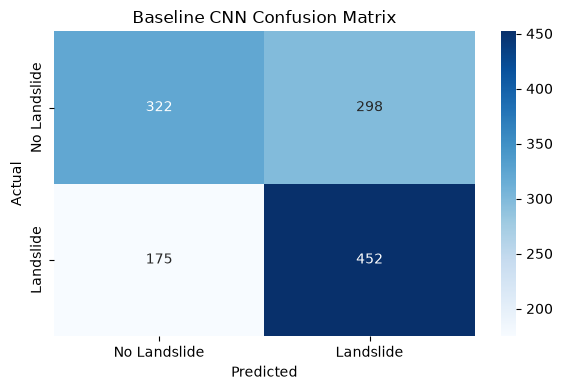


Final Results: {'name': 'Baseline CNN', 'f1': 0.6564996368917938, 'auc': 0.6606214950866902, 'specificity': np.float64(0.5193548387096775), 'tp': np.int64(452), 'tn': np.int64(322), 'fp': np.int64(298), 'fn': np.int64(175)}


In [14]:
baseline_model = BaselineCNN().to(device)

# Handle class imbalance
pos_count = df_train['label'].sum()
neg_count = len(df_train) - pos_count
pos_weight = torch.tensor([neg_count / pos_count]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print('Training Baseline CNN...')
baseline_model = train_model(
    baseline_model, criterion, optimizer, scheduler,
    num_epochs=20, patience=5,
    save_path='saved_models/baseline_cnn_best.pth'  # Unique save path
)
results = evaluate_model(baseline_model, 'Baseline CNN')
print('\nFinal Results:', results)

In [15]:
# Save Baseline CNN model
os.makedirs("saved_models", exist_ok=True)
torch.save(baseline_model.state_dict(), "saved_models/baseline_cnn_final.pth")
print("Baseline CNN model saved to saved_models/baseline_cnn_final.pth")

Baseline CNN model saved to saved_models/baseline_cnn_final.pth
